# Ngày 2 — Split, SMOTE & Mô hình cơ sở

Notebook này thực hiện đúng các task của **Ngày 2** trong lộ trình 4 ngày: chia
train/test theo phân tầng, chuẩn hoá dữ liệu đúng cách (không rò rỉ), xử lý mất
cân bằng bằng SMOTE, huấn luyện baseline, và so sánh nhanh nhiều mô hình.

> Chạy từ trong thư mục `notebooks/` (đường dẫn tương đối `../data`, `../images`, `../models`).
> Input: `data/processed/attrition_encoded.csv` (sản phẩm của Ngày 1).


In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'
PALETTE = {0: '#3d5a80', 1: '#e07a5f'}


## 1. Load dữ liệu đã xử lý từ Ngày 1

In [2]:
df = pd.read_csv("../data/processed/attrition_encoded.csv")
print("Kích thước:", df.shape)

X = df.drop(columns=['Attrition'])
y = df['Attrition']


Kích thước: (1470, 45)


## 2. Stratified Train/Test Split

`stratify=y` đảm bảo tỷ lệ Attrition Yes/No được giữ nguyên ở cả 2 tập — kiểm tra lại ngay dưới đây.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Tỷ lệ Attrition=1 ở Train: {y_train.mean():.4f}")
print(f"Tỷ lệ Attrition=1 ở Test:  {y_test.mean():.4f}")


Train: (1176, 44), Test: (294, 44)
Tỷ lệ Attrition=1 ở Train: 0.1616
Tỷ lệ Attrition=1 ở Test:  0.1599


## 3. Chuẩn hoá dữ liệu số — StandardScaler (chỉ `fit` trên Train)

> ⚠️ Quy tắc vàng chống rò rỉ dữ liệu: `scaler.fit_transform()` **chỉ** gọi trên `X_train`.
> Với `X_test`, chỉ gọi `scaler.transform()` — dùng lại đúng mean/std đã học từ train.

In [4]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Số cột numeric sẽ chuẩn hoá: {len(numeric_cols)}")

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Đã chuẩn hoá xong.")


Số cột numeric sẽ chuẩn hoá: 23
Đã chuẩn hoá xong.


## 4. SMOTE — chỉ áp dụng trên Train

SMOTE sinh mẫu tổng hợp cho lớp thiểu số (Attrition=1) bằng nội suy k-nearest-neighbors,
**không** đụng vào `X_test` — giữ tập test nguyên vẹn để đánh giá khách quan.

In [5]:
print("Trước SMOTE:", Counter(y_train))

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Sau SMOTE:  ", Counter(y_train_res))


Trước SMOTE: Counter({0: 986, 1: 190})
Sau SMOTE:   Counter({0: 986, 1: 986})


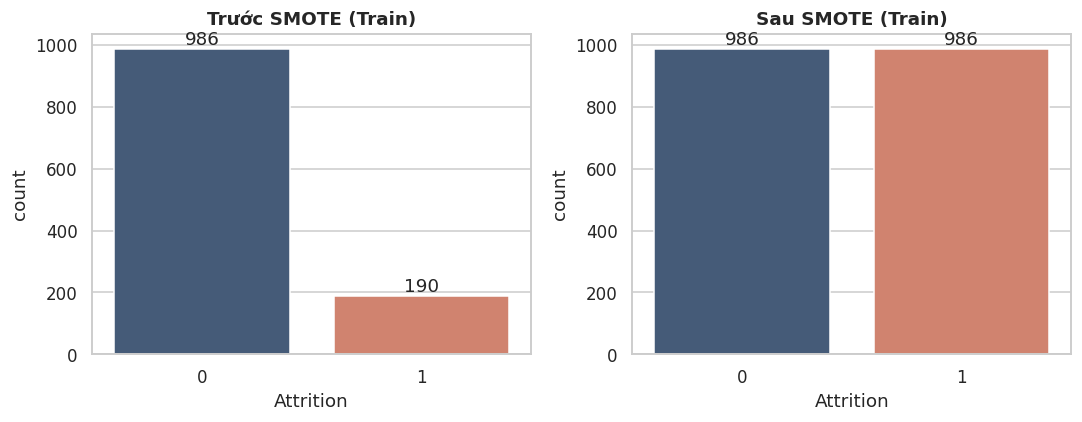

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x=y_train, hue=y_train, palette=PALETTE, legend=False, ax=axes[0])
axes[0].set_title("Trước SMOTE (Train)")
axes[0].set_xlabel("Attrition")

sns.countplot(x=y_train_res, hue=y_train_res, palette=PALETTE, legend=False, ax=axes[1])
axes[1].set_title("Sau SMOTE (Train)")
axes[1].set_xlabel("Attrition")

for ax in axes:
    for container in ax.containers:
        ax.bar_label(container)

plt.tight_layout()
plt.savefig("../images/04_smote_before_after.png", bbox_inches='tight')
plt.show()


## 5. Mô hình cơ sở — Logistic Regression

In [7]:
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train_res, y_train_res)

y_pred = baseline.predict(X_test_scaled)
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))


              precision    recall  f1-score   support

          No       0.91      0.93      0.92       247
         Yes       0.56      0.49      0.52        47

    accuracy                           0.86       294
   macro avg       0.73      0.71      0.72       294
weighted avg       0.85      0.86      0.85       294



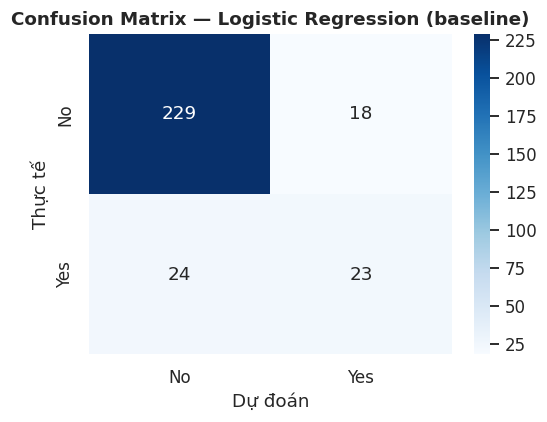

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title("Confusion Matrix — Logistic Regression (baseline)")
plt.ylabel("Thực tế")
plt.xlabel("Dự đoán")
plt.tight_layout()
plt.savefig("../images/05_baseline_confusion_matrix.png", bbox_inches='tight')
plt.show()


## 6. So sánh nhanh nhiều mô hình (Stratified 5-Fold CV)

Chạy với tham số mặc định/nhẹ trước — việc tune sâu (RandomizedSearchCV) để dành cho
Ngày 3, chỉ áp dụng lên 1-2 ứng viên tốt nhất ở đây để tiết kiệm thời gian.

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['recall', 'precision', 'f1', 'average_precision']

results = {}
for name, model in models.items():
    scores = cross_validate(model, X_train_res, y_train_res, cv=cv, scoring=scoring, n_jobs=-1)
    results[name] = {m: scores[f'test_{m}'].mean() for m in scoring}
    print(f"Đã xong: {name}")

results_df = pd.DataFrame(results).T
results_df.columns = ['Recall', 'Precision', 'F1', 'PR-AUC']
results_df = results_df.sort_values('Recall', ascending=False)
results_df.round(4)


Đã xong: Logistic Regression


Đã xong: Random Forest


Đã xong: XGBoost


Đã xong: LightGBM


Đã xong: CatBoost


,Recall,Precision,F1,PR-AUC
Random Forest,0.9087,0.9642,0.9353,0.9863
CatBoost,0.9087,0.9695,0.9377,0.9858
LightGBM,0.9026,0.9541,0.9272,0.9825
XGBoost,0.9006,0.9521,0.9254,0.9812
Logistic Regression,0.8793,0.9237,0.9006,0.9699


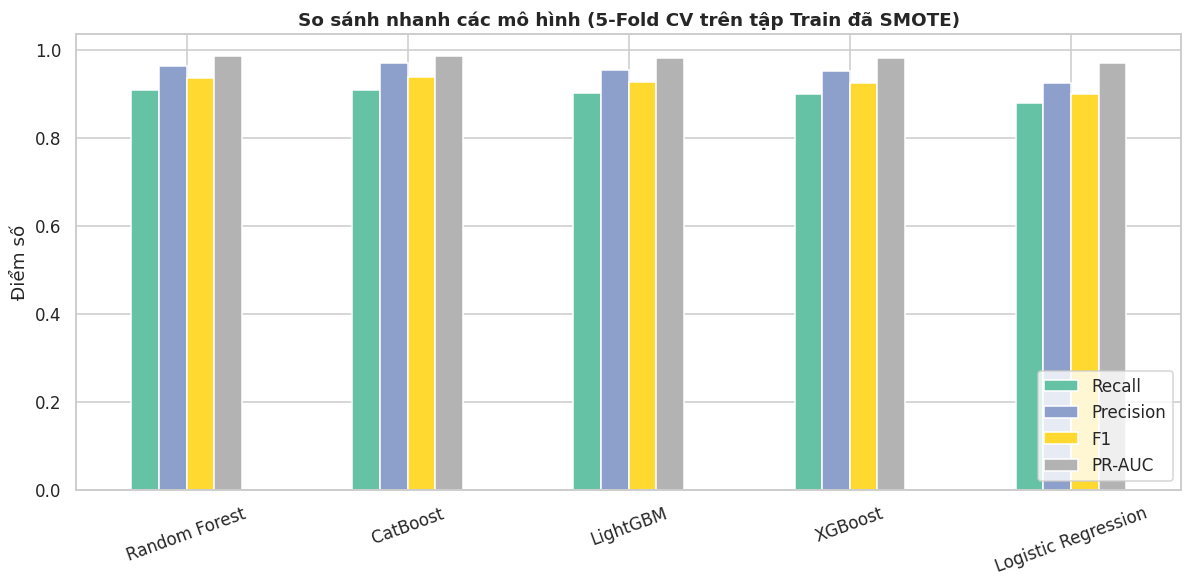

In [10]:
ax = results_df.plot(kind='bar', figsize=(11, 5.5), colormap='Set2', rot=20)
ax.set_title("So sánh nhanh các mô hình (5-Fold CV trên tập Train đã SMOTE)")
ax.set_ylabel("Điểm số")
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("../images/06_model_comparison_cv.png", bbox_inches='tight')
plt.show()


In [11]:
top2 = results_df.head(2).index.tolist()
print("2 ứng viên tốt nhất để tune sâu ở Ngày 3 (theo Recall):", top2)


2 ứng viên tốt nhất để tune sâu ở Ngày 3 (theo Recall): ['Random Forest', 'CatBoost']


## 7. Lưu kết quả & đối tượng cần cho Ngày 3

In [12]:
os.makedirs("../models", exist_ok=True)

results_df.to_csv("../data/processed/day2_model_comparison.csv")
joblib.dump(scaler, "../models/scaler.pkl")

X_train_res.to_csv("../data/processed/X_train_smote.csv", index=False)
y_train_res.to_csv("../data/processed/y_train_smote.csv", index=False)
X_test_scaled.to_csv("../data/processed/X_test_scaled.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)

print("Đã lưu xong: scaler.pkl, X_train_smote.csv, y_train_smote.csv, X_test_scaled.csv, y_test.csv")


Đã lưu xong: scaler.pkl, X_train_smote.csv, y_train_smote.csv, X_test_scaled.csv, y_test.csv


## Tổng kết Ngày 2

- ✅ Train/test split có `stratify=y` — tỷ lệ lớp được bảo toàn ở cả 2 tập
- ✅ StandardScaler chỉ `fit` trên train, `transform` trên test — không rò rỉ dữ liệu
- ✅ SMOTE áp dụng đúng — chỉ trên `X_train`, sau khi split
- ✅ Baseline Logistic Regression chạy được, có confusion matrix
- ✅ So sánh nhanh 5 mô hình bằng Stratified 5-Fold CV, đã xác định top 2 ứng viên

**Bước tiếp theo (Ngày 3):** RandomizedSearchCV tune sâu top 2 ứng viên → đánh giá đầy đủ
(Precision/Recall/F1/PR-AUC/ROC-AUC) → Threshold Tuning → lưu mô hình cuối cùng.
